In [119]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import json

In [58]:
import json

# Open and read the JSON file
with open('./rgb_1_final.json', 'r') as f:
    data = json.load(f)

# Print the data
print(data.keys())

dict_keys(['loss', 'class_acc', 'obj_acc', 'noobj_acc', 'map', 'ap_per_class'])


In [60]:
def plot_loss_epoch_curve(loss_values):
    sns.set(style="darkgrid") 
    
    epochs = list(range(len(loss_values)))
    
    plt.figure(figsize=(10, 6))  
    sns.lineplot(x=epochs, y=loss_values, color='b', label='Loss', linewidth=2)
    
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Train loss vs Epochs', fontsize=14)
    
    plt.legend()
    plt.show()

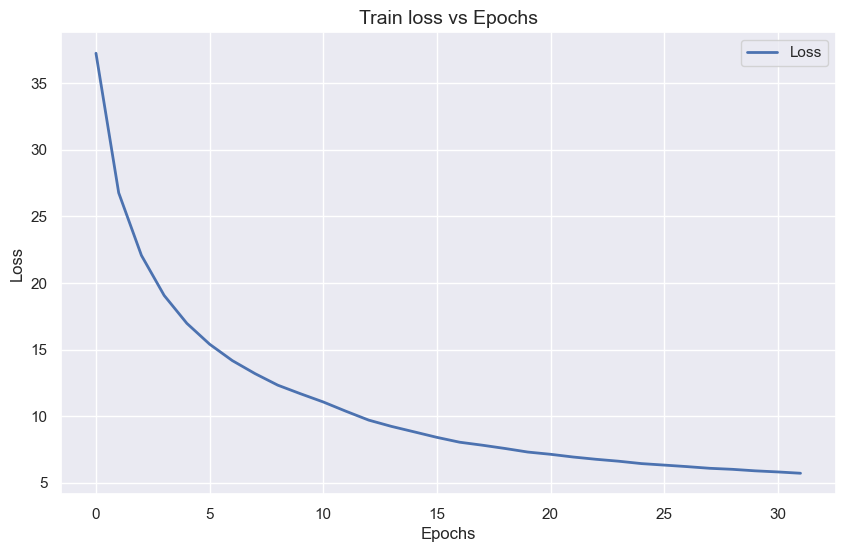

In [61]:
plot_loss_epoch_curve(data['loss'])

In [62]:
def plot_scores_epoch_curve(scores, name):
    sns.set(style="darkgrid") 
    
    epochs = list(range(len(scores)))
    class_accuracy_list = []
    for item in scores:
        for key, value in item.items():
            class_accuracy_list.append(value)
    
    plt.figure(figsize=(10, 6))  
    sns.lineplot(x=epochs, y=class_accuracy_list, color='b', label='Loss', linewidth=2)
    
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel(f'{name.title()}', fontsize=12)
    plt.title(f'{name.title()} vs Epochs', fontsize=14)
    
    plt.legend()
    plt.show()

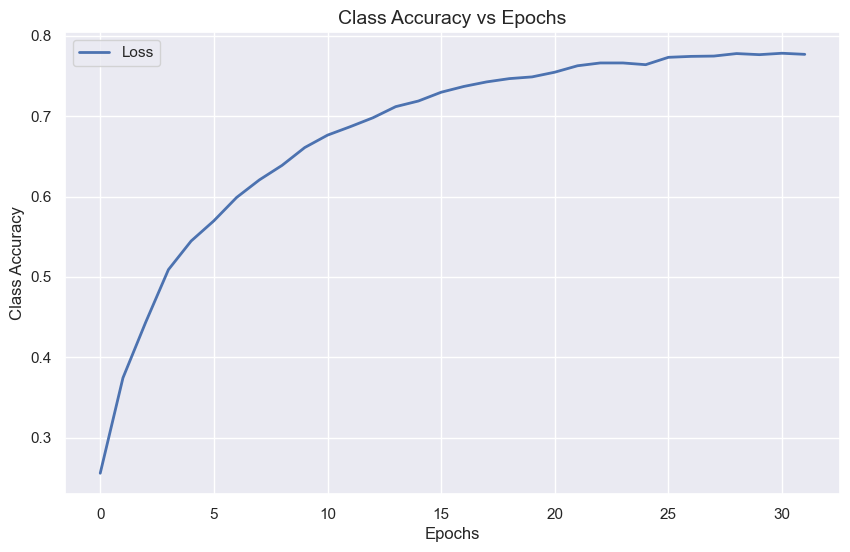

In [63]:
plot_scores_epoch_curve(data['class_acc'], "class accuracy")

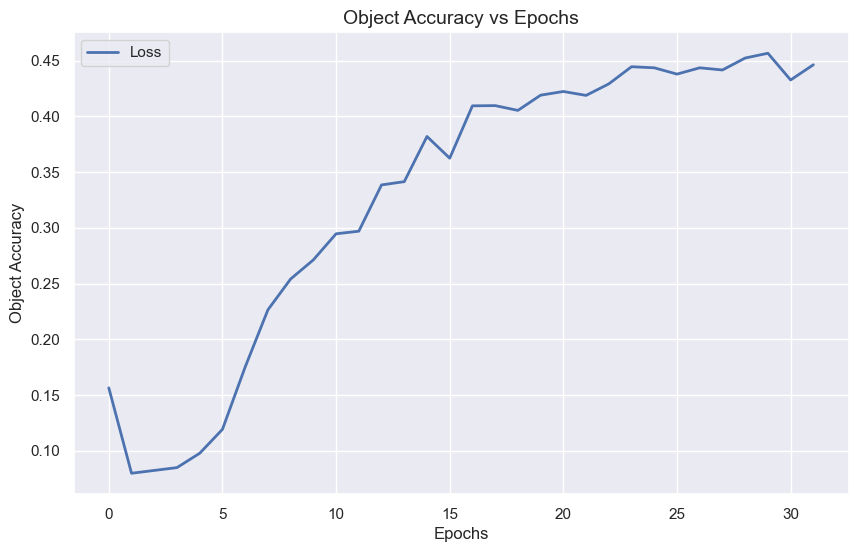

In [64]:
plot_scores_epoch_curve(data['obj_acc'], "object accuracy")

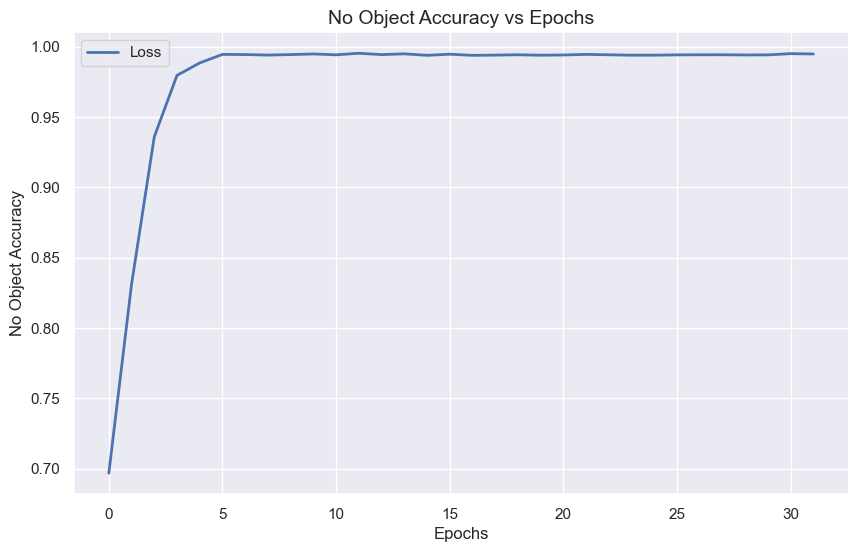

In [65]:
plot_scores_epoch_curve(data['noobj_acc'], "no object accuracy")

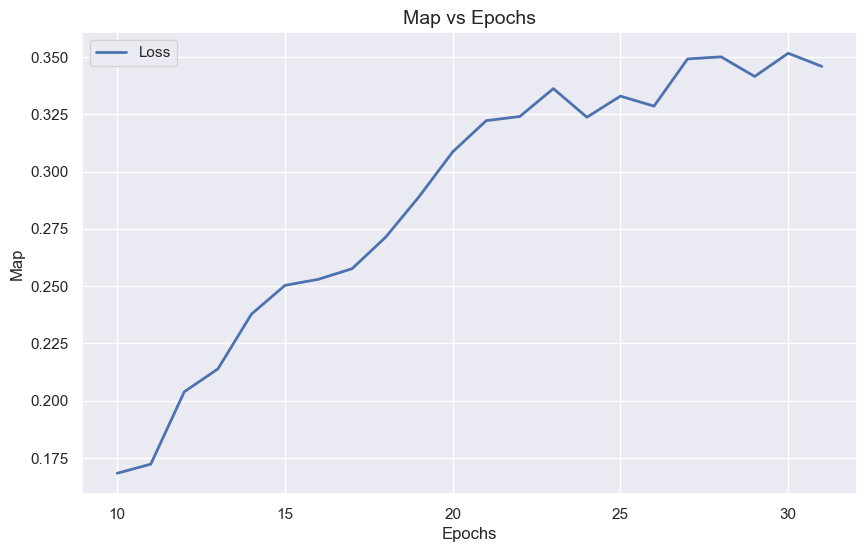

In [67]:
plot_scores_epoch_curve(data['map'], "MAP")


In [140]:
def ap_per_class(ap_per_class):
    class_ap_dict = {}
    
    # get list of values for each class
    for epoch_dict in ap_per_class:
        for epoch_num, class_list in epoch_dict.items():
            if class_list is None: 
                continue
            for category_dict in class_list:
                for category, value in category_dict.items():
                    if category not in class_ap_dict:
                        class_ap_dict[category] = []
                    if value is None:
                        class_ap_dict[category].extend([0])
                    else: 
                        if not isinstance(value, list):
                            class_ap_dict[category].extend([value*100])
                        else:
                            class_ap_dict[category].extend([v * 100 for v in value])
    
    # plot
    sns.set(style="darkgrid") 
    cmap = plt.colormaps['tab20']
    
    epochs = list(range(len(ap_per_class)))[10:]
    for idx, (label, values) in enumerate(class_ap_dict.items()):
        plt.plot(epochs, values, label=label.title(), color=cmap(idx))
        
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel("AP Scores per category (in %)", fontsize=12)
    plt.title(f'AP Score per Category vs Epochs', fontsize=14)
    
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    
    plt.show()

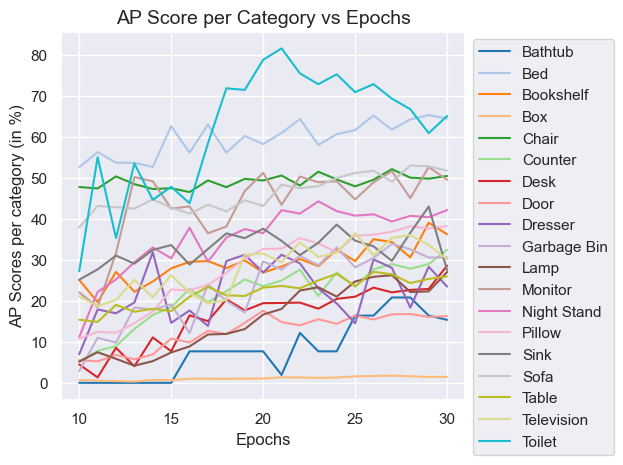

In [141]:
ap_per_class(data['ap_per_class'])